## Spatial Autoencoder — Checkerboard Inference Demo

Load a Landsat thermal scene, run checkerboard-masked reconstruction via the SpatialAutoencoderInferencer, and plot original vs reconstructed side by side.

### 1. Load the Landsat scene via LandsatDataBuilder

In [73]:
import os
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt

# Ensure project root is on the path
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.landsat_dataset_builder import LandsatDataBuilder





THERMAL_TIF = os.path.join(
    PROJECT_ROOT,
    "tests/test_payloads/phase_2/Set-3/Thermal/LC09_L2SP_150044_20251009_20251010_02_T1_ST_B10.TIF",
)
builder = LandsatDataBuilder(
    file_source_configuration=FileSourceConfig(source_path=THERMAL_TIF)
)
vendable = builder.vend_dataset()

print(f"Thermal cube shape: {vendable.normalized_thermal_cube.shape}")
print(f"Validity mask shape: {vendable.validity_cube.shape}")

Using device: mps
Max Temp = 51.58749771118164
Min Temp = -124.1500015258789
Masked Array
(40670474, 1)
[25.58662033 26.92990112 34.11116028 38.84170151 41.47357559]
Anchors Set to [[-10.        ]
 [  5.        ]
 [ 34.11116028]
 [ 38.84170151]
 [ 41.47357559]]
22.111160278320312
[0 1]
Thermal cube shape: (1, 7721, 7581)
Validity mask shape: (1, 7721, 7581)


### 2. Initialize inferencer

In [81]:
from app.models.training.inference_config import InferenceConfig
from app.foundation_models.inferencers.inferencer_factory import get_inferencer

PATCH_SIZE = 512

CHECKPOINT = os.path.join(
    PROJECT_ROOT,
    "checkpoints/spatial_autoencoder_v8.1.0_epoch29.pt",
)

config = InferenceConfig(
    foundation_model_name="spatial_autoencoder",
    model_config={
        "model_type": "spatial_autoencoder",
        "in_channels": 1,
        "base_channels": 32,
        "num_stages": 4,
    },
    checkpoint_path=CHECKPOINT,
    patch_size=PATCH_SIZE,
    checkerboard_cell_size=2,
    pixel_stats_path="/Users/ashwinravi/Desktop/Code Repos/hsi-anomaly-foundations-allotrope/app/constants/thermal_pixel_consts.json"
)

inferencer = get_inferencer(config)

### 3. Run full-scene checkerboard reconstruction

In [ ]:
scene_tensor = torch.from_numpy(vendable.normalized_thermal_cube).float()  # (1, H, W)
mask_tensor = torch.from_numpy(vendable.validity_cube).float()              # (1, H, W)

print(f"Scene: {scene_tensor.shape}, Mask: {mask_tensor.shape}")

reconstruction = inferencer.predict_full_scene(scene_tensor, mask_tensor)  # (1, H, W)

print(f"Reconstruction: {reconstruction.shape}")
print(f"Original range: [{(scene_tensor*mask_tensor).min():.2f}, {(scene_tensor*mask_tensor).max():.2f}]")
print(f"Recon range:    [{(reconstruction*mask_tensor).min():.2f}, {(reconstruction*mask_tensor).max():.2f}]")

Scene: torch.Size([1, 7721, 7581]), Mask: torch.Size([1, 7721, 7581])
Reconstruction: torch.Size([1, 7721, 7581])
Original range: [-124.15, 51.59]
Recon range:    [0.00, 40.14]


### 4. Plot original vs reconstruction (own scales) and residual

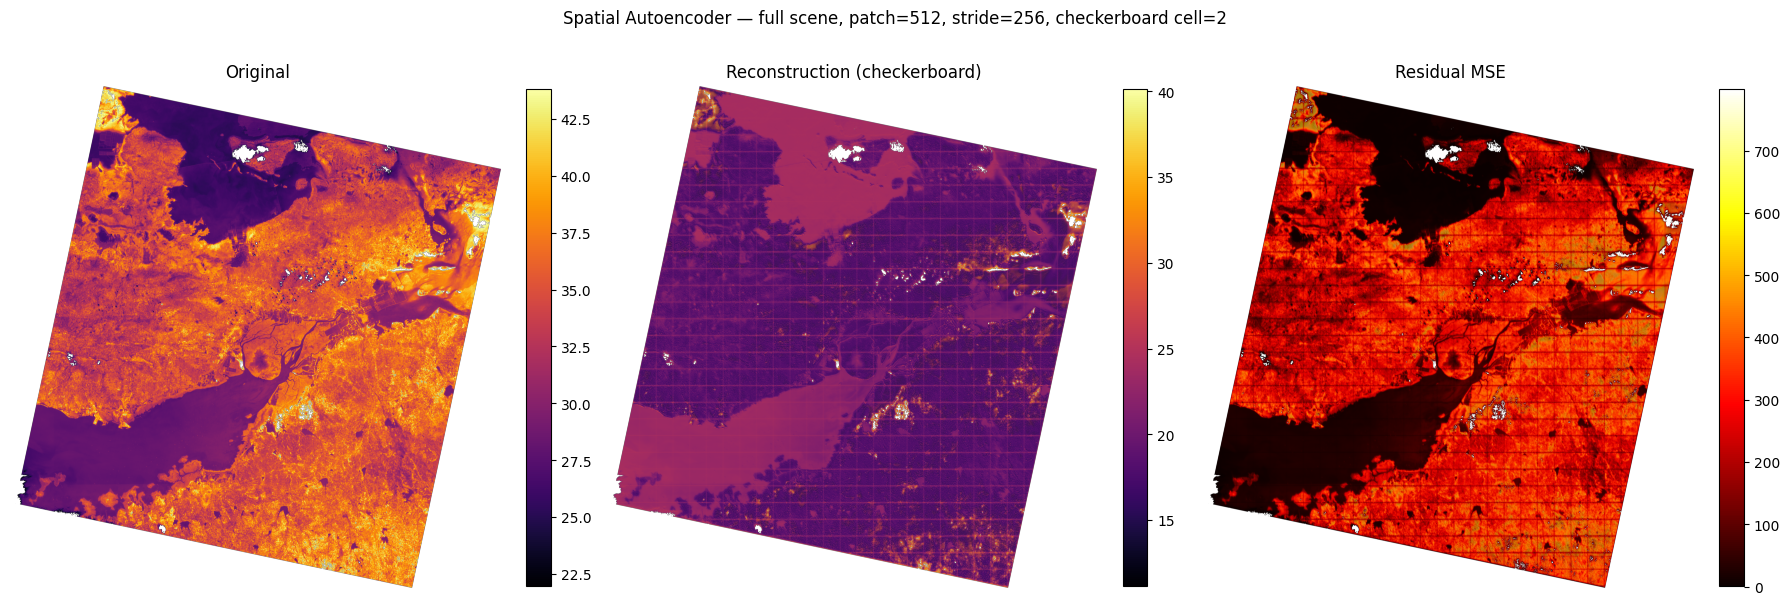

In [83]:
original = scene_tensor.squeeze().cpu().numpy()         # (H, W)
recon = reconstruction.squeeze().cpu().numpy()           # (H, W)
mask = mask_tensor.squeeze().cpu().numpy()               # (H, W)
residual = (original - recon) ** 2 * mask                # MSE, masked

# Mask invalid pixels for display
original_masked = np.ma.masked_where(mask == 0, original)
recon_masked = np.ma.masked_where(mask == 0, recon)
residual_masked = np.ma.masked_where(mask == 0, residual)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Each image on its own color scale
im0 = axes[0].imshow(original_masked, cmap="inferno")
axes[0].set_title("Original")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(recon_masked, cmap="inferno")
axes[1].set_title("Reconstruction (checkerboard)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(residual_masked, cmap="hot")
axes[2].set_title("Residual MSE")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Spatial Autoencoder — full scene, "
    f"patch={PATCH_SIZE}, stride={config.stride or PATCH_SIZE // 2}, "
    f"checkerboard cell={config.checkerboard_cell_size}",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 4b. Anomaly highlights (99.5th percentile)

P99.95 threshold: 660.7850
Pixels above threshold: 20162 / 40323508
Ground truth shape: (7721, 7581), unique values: [0. 1.]


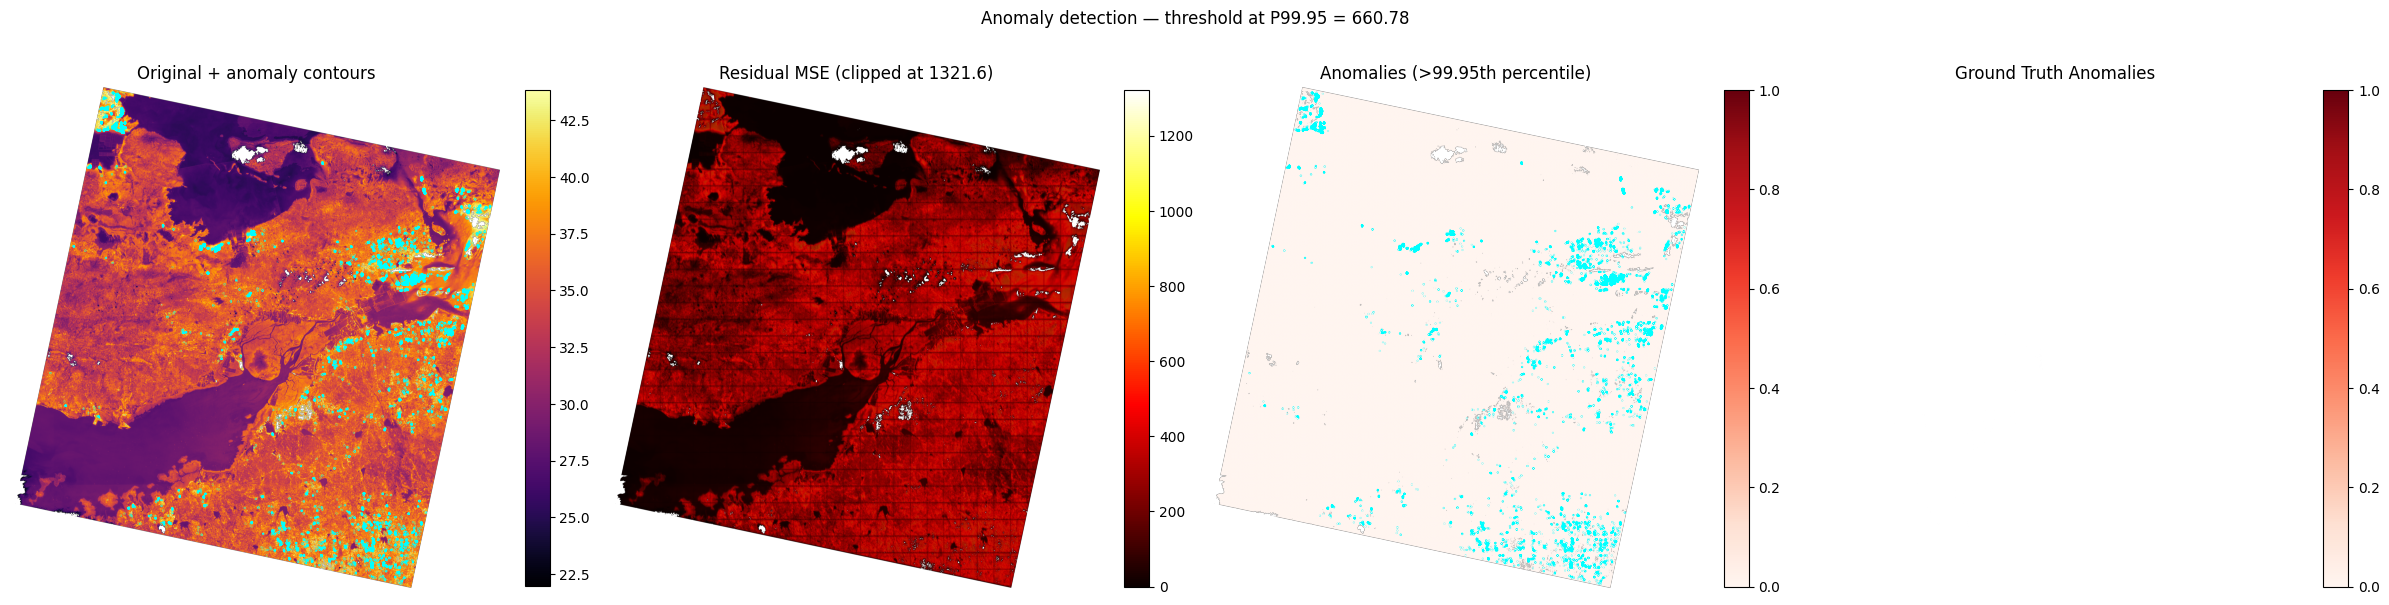

In [84]:
PERCENTILE = 99.95

# Compute threshold on valid pixels only
valid_residuals = residual[mask == 1]
threshold = np.percentile(valid_residuals, PERCENTILE)
print(f"P{PERCENTILE} threshold: {threshold:.4f}")
print(f"Pixels above threshold: {(valid_residuals > threshold).sum()} / {valid_residuals.size}")

# Binary anomaly mask: above threshold and valid
anomaly_binary = ((residual > threshold) & (mask == 1)).astype(float)

# Load ground truth
import rasterio
gt_path = os.path.join(
    os.path.dirname(THERMAL_TIF),
    "Ground truth",
    "Groundtruth thermal anomalies.tif",
)
with rasterio.open(gt_path) as src:
    gt_data = src.read(1)  # (H, W)
print(f"Ground truth shape: {gt_data.shape}, unique values: {np.unique(gt_data)}")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Original with anomaly contours overlaid
im0 = axes[0].imshow(original_masked, cmap="inferno")
axes[0].contour(anomaly_binary, levels=[0.5], colors="cyan", linewidths=1.5)
axes[0].set_title("Original + anomaly contours")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Residual MSE clipped at threshold to show detail in the hot tail
im1 = axes[1].imshow(residual_masked, cmap="hot", vmin=0, vmax=threshold * 2)
axes[1].set_title(f"Residual MSE (clipped at {threshold*2:.1f})")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Binary anomaly map
anomaly_display = np.ma.masked_where(mask == 0, anomaly_binary)
im2 = axes[2].imshow(anomaly_display, cmap="Reds", vmin=0, vmax=1)
axes[2].contour(anomaly_binary, levels=[0.5], colors="cyan", linewidths=1.5)
axes[2].set_title(f"Anomalies (>{PERCENTILE}th percentile)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Ground truth
gt_masked = np.ma.masked_where(gt_data == 0, gt_data)
im3 = axes[3].imshow(gt_masked, cmap="Reds", vmin=0, vmax=gt_data.max())
axes[3].set_title("Ground Truth Anomalies")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Anomaly detection — threshold at P{PERCENTILE} = {threshold:.2f}",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 4c. ROC Curve — Model vs Ground Truth

Valid pixels: 40,323,508
Ground truth positives: 173
Ground truth negatives: 40,323,335


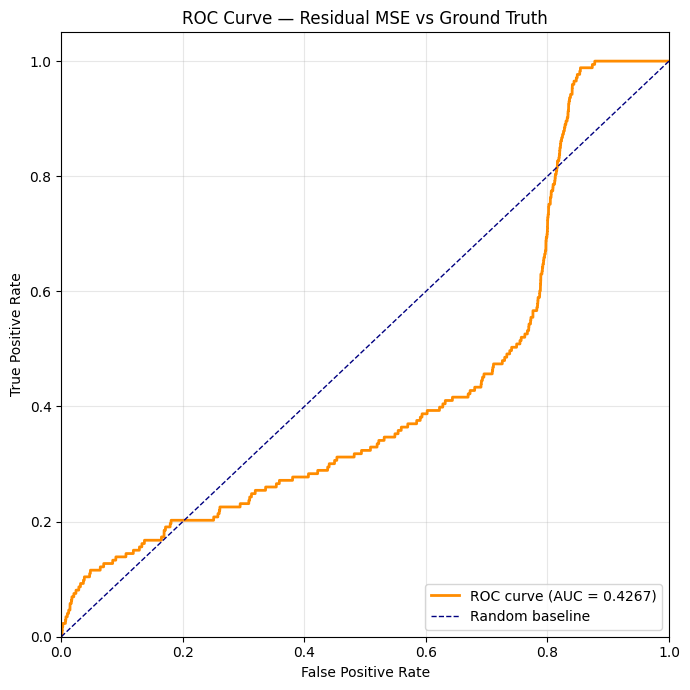


AUC: 0.4267


In [85]:
from sklearn.metrics import roc_curve, auc

# Flatten to valid pixels only
valid_mask = mask.astype(bool).ravel()
scores = residual.ravel()[valid_mask]
gt_labels = gt_data.ravel()[valid_mask].astype(int)

print(f"Valid pixels: {valid_mask.sum():,}")
print(f"Ground truth positives: {gt_labels.sum():,}")
print(f"Ground truth negatives: {(gt_labels == 0).sum():,}")

fpr, tpr, roc_thresholds = roc_curve(gt_labels, scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random baseline")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Residual MSE vs Ground Truth")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC: {roc_auc:.4f}")

### 4d. Precision & Recall vs Percentile Threshold (99.5 → 100)

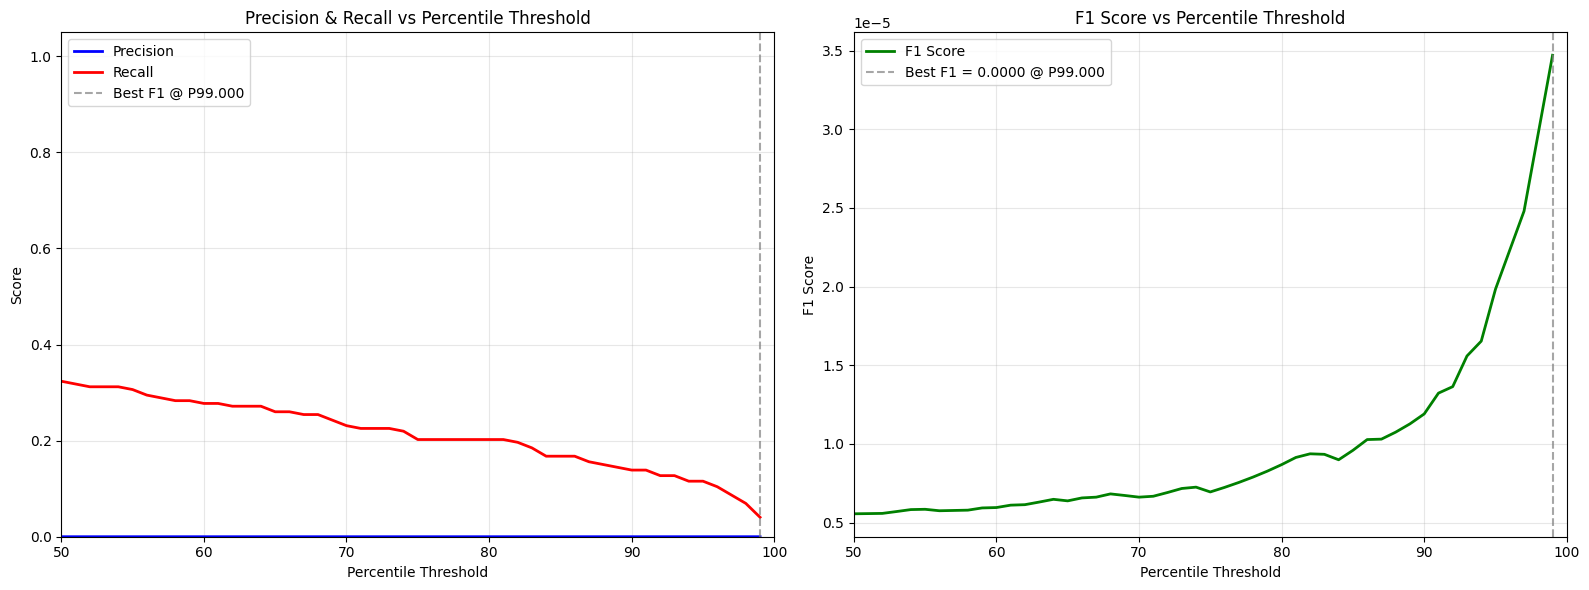

Best F1: 0.0000 at P99.000
  Precision: 0.0000
  Recall:    0.0405


In [86]:
percentiles = np.arange(50, 100.0, 1)
precisions = []
recalls = []
f1_scores = []

for p in percentiles:
    thresh = np.percentile(scores, p)
    predicted = (scores > thresh).astype(int)
    tp = ((predicted == 1) & (gt_labels == 1)).sum()
    fp = ((predicted == 1) & (gt_labels == 0)).sum()
    fn = ((predicted == 0) & (gt_labels == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

precisions = np.array(precisions)
recalls = np.array(recalls)
f1_scores = np.array(f1_scores)

best_idx = np.argmax(f1_scores)
best_pct = percentiles[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Precision & Recall vs Percentile
ax1.plot(percentiles, precisions, color="blue", lw=2, label="Precision")
ax1.plot(percentiles, recalls, color="red", lw=2, label="Recall")
ax1.axvline(best_pct, color="gray", linestyle="--", alpha=0.7, label=f"Best F1 @ P{best_pct:.3f}")
ax1.set_xlabel("Percentile Threshold")
ax1.set_ylabel("Score")
ax1.set_title("Precision & Recall vs Percentile Threshold")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([50, 100.0])
ax1.set_ylim([0.0, 1.05])

# F1 vs Percentile
ax2.plot(percentiles, f1_scores, color="green", lw=2, label="F1 Score")
ax2.axvline(best_pct, color="gray", linestyle="--", alpha=0.7, label=f"Best F1 = {f1_scores[best_idx]:.4f} @ P{best_pct:.3f}")
ax2.set_xlabel("Percentile Threshold")
ax2.set_ylabel("F1 Score")
ax2.set_title("F1 Score vs Percentile Threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([50, 100.0])

plt.tight_layout()
plt.show()

print(f"Best F1: {f1_scores[best_idx]:.4f} at P{best_pct:.3f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")

### 4e. Ground Truth Anomaly Temperatures vs Scene Distribution

Scene temperature stats (valid pixels):
  Mean: 33.52, Std: 4.13
  Min:  18.02, Max: 51.59
  P1:   25.40, P99: 42.67

Anomaly pixel temperatures (205 pixels):
  Mean: 36.55, Std: 6.48
  Min:  28.54, Max: 49.61

Z-scores of anomaly pixels (relative to scene):
  Mean: 0.73, Std: 1.57
  Min:  -1.21, Max: 3.89
  Anomalies below -2σ: 0
  Anomalies within ±2σ: 147
  Anomalies above +2σ: 58


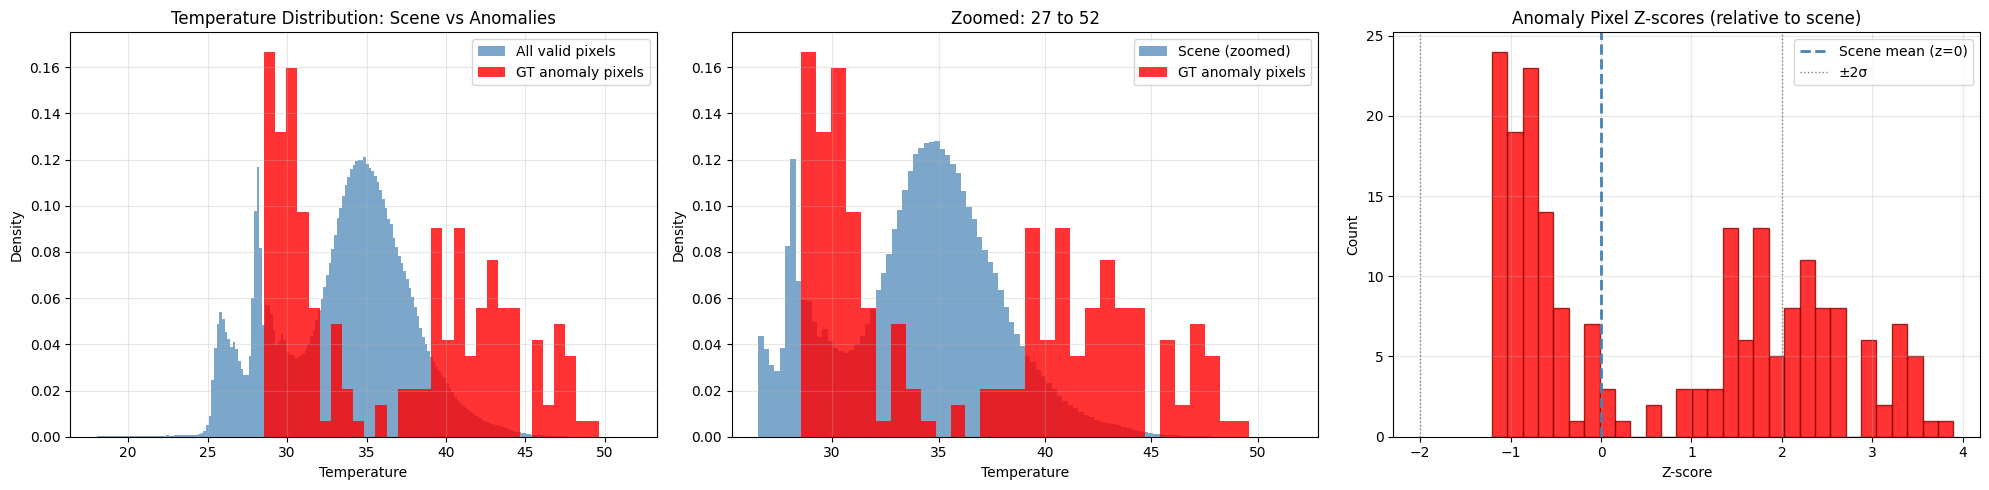


Percentile rank of anomaly pixels within scene distribution:
  Mean percentile: 61.90%
  Min percentile:  16.74%
  Max percentile:  100.00%
  Anomalies in top 1%:   48
  Anomalies in top 5%:   81
  Anomalies in bottom 5%: 0


In [ ]:
valid_temps = original[mask == 1]
anomaly_temps = original[(gt_data == 1) & (mask == 1)]
normal_temps = original[(gt_data == 0) & (mask == 1)]

scene_mean = valid_temps.mean()
scene_std = valid_temps.std()
anomaly_zscores = (anomaly_temps - scene_mean) / scene_std

print(f"Scene temperature stats (valid pixels):")
print(f"  Mean: {scene_mean:.2f}, Std: {scene_std:.2f}")
print(f"  Min:  {valid_temps.min():.2f}, Max: {valid_temps.max():.2f}")
print(f"  P1:   {np.percentile(valid_temps, 1):.2f}, P99: {np.percentile(valid_temps, 99):.2f}")
print()
print(f"Anomaly pixel temperatures ({len(anomaly_temps)} pixels):")
print(f"  Mean: {anomaly_temps.mean():.2f}, Std: {anomaly_temps.std():.2f}")
print(f"  Min:  {anomaly_temps.min():.2f}, Max: {anomaly_temps.max():.2f}")
print()
print(f"Z-scores of anomaly pixels (relative to scene):")
print(f"  Mean: {anomaly_zscores.mean():.2f}, Std: {anomaly_zscores.std():.2f}")
print(f"  Min:  {anomaly_zscores.min():.2f}, Max: {anomaly_zscores.max():.2f}")
print(f"  Anomalies below -2σ: {(anomaly_zscores < -2).sum()}")
print(f"  Anomalies within ±2σ: {((anomaly_zscores >= -2) & (anomaly_zscores <= 2)).sum()}")
print(f"  Anomalies above +2σ: {(anomaly_zscores > 2).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Histogram: scene vs anomaly temperatures
axes[0].hist(valid_temps, bins=200, density=True, alpha=0.7, color="steelblue", label="All valid pixels")
axes[0].hist(anomaly_temps, bins=30, density=True, alpha=0.8, color="red", label="GT anomaly pixels")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Density")
axes[0].set_title("Temperature Distribution: Scene vs Anomalies")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed histogram around the anomaly range
anom_lo = anomaly_temps.min() - 2
anom_hi = anomaly_temps.max() + 2
zoom_mask = (valid_temps >= anom_lo) & (valid_temps <= anom_hi)
axes[1].hist(valid_temps[zoom_mask], bins=100, density=True, alpha=0.7, color="steelblue", label="Scene (zoomed)")
axes[1].hist(anomaly_temps, bins=30, density=True, alpha=0.8, color="red", label="GT anomaly pixels")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Zoomed: {anom_lo:.0f} to {anom_hi:.0f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Z-score distribution of anomaly pixels
axes[2].hist(anomaly_zscores, bins=30, alpha=0.8, color="red", edgecolor="darkred")
axes[2].axvline(0, color="steelblue", lw=2, linestyle="--", label="Scene mean (z=0)")
axes[2].axvline(-2, color="gray", lw=1, linestyle=":", label="±2σ")
axes[2].axvline(2, color="gray", lw=1, linestyle=":")
axes[2].set_xlabel("Z-score")
axes[2].set_ylabel("Count")
axes[2].set_title("Anomaly Pixel Z-scores (relative to scene)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Percentile rank of each anomaly pixel within the scene distribution
anomaly_percentiles = np.array([
    (valid_temps < t).sum() / len(valid_temps) * 100
    for t in anomaly_temps
])
print(f"\nPercentile rank of anomaly pixels within scene distribution:")
print(f"  Mean percentile: {anomaly_percentiles.mean():.2f}%")
print(f"  Min percentile:  {anomaly_percentiles.min():.2f}%")
print(f"  Max percentile:  {anomaly_percentiles.max():.2f}%")
print(f"  Anomalies in top 1%:   {(anomaly_percentiles > 99).sum()}")
print(f"  Anomalies in top 5%:   {(anomaly_percentiles > 95).sum()}")
print(f"  Anomalies in bottom 5%: {(anomaly_percentiles < 5).sum()}")

### 5. Visualize the checkerboard mask

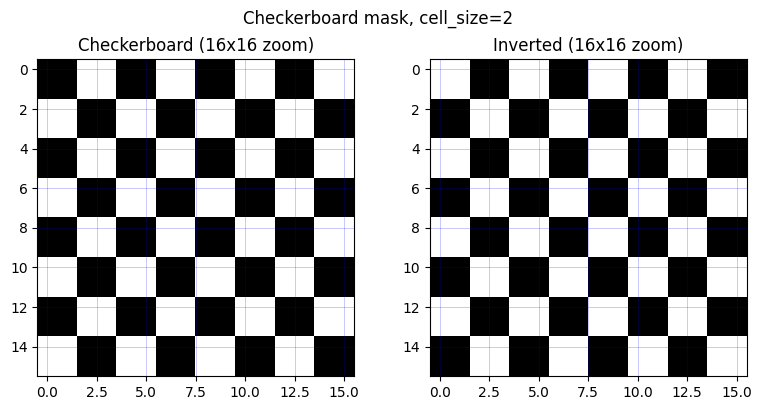

In [ ]:
# Show what the checkerboard mask looks like (zoomed into top-left 16x16)
checker = inferencer._build_checkerboard(PATCH_SIZE, PATCH_SIZE, invert=False)
checker_np = checker.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(checker_np[:16, :16], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Checkerboard (16x16 zoom)")
axes[0].grid(True, linewidth=0.5, color="blue", alpha=0.3)

axes[1].imshow(1 - checker_np[:16, :16], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Inverted (16x16 zoom)")
axes[1].grid(True, linewidth=0.5, color="blue", alpha=0.3)

plt.suptitle(f"Checkerboard mask, cell_size={config.checkerboard_cell_size}")
plt.tight_layout()
plt.show()